<h2>Installing Dependencies</h2>

In [4]:
!pip install pandas openpyxl scikit-learn matplotlib seaborn numpy


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<h3>Imports</h3>

In [15]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# ── Plot style
COLORS = {
    'linear':   '#4C72B0',
    'poly':     '#DD8452',
    'sigmoid':  '#55A868',
    'rbf':      '#C44E52',
    'knn':      '#8172B2',
    'logreg':   '#937860',
    'knn_raw':  '#DA8BC3',
    'knn_proc': '#8C8C8C',
    'bg':       '#F8F9FA',
    'grid':     '#E5E5E5',
}
MODEL_PALETTE = [COLORS['linear'], COLORS['poly'], COLORS['sigmoid'],
                 COLORS['rbf'], COLORS['knn'], COLORS['logreg']]

plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.facecolor':     COLORS['bg'],
    'figure.facecolor':   'white',
    'axes.grid':          True,
    'grid.color':         COLORS['grid'],
    'grid.linewidth':     0.8,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'font.size':          11,
})
print("✔ All imports successful")

✔ All imports successful


<h3>Load dataset</h3>

In [16]:
df = pd.read_excel('Telco_customer_churn.xlsx')
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Shape: (7043, 33)

Columns:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


<h3>EDA</h3>

── Data Types ──────────────────────
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype:

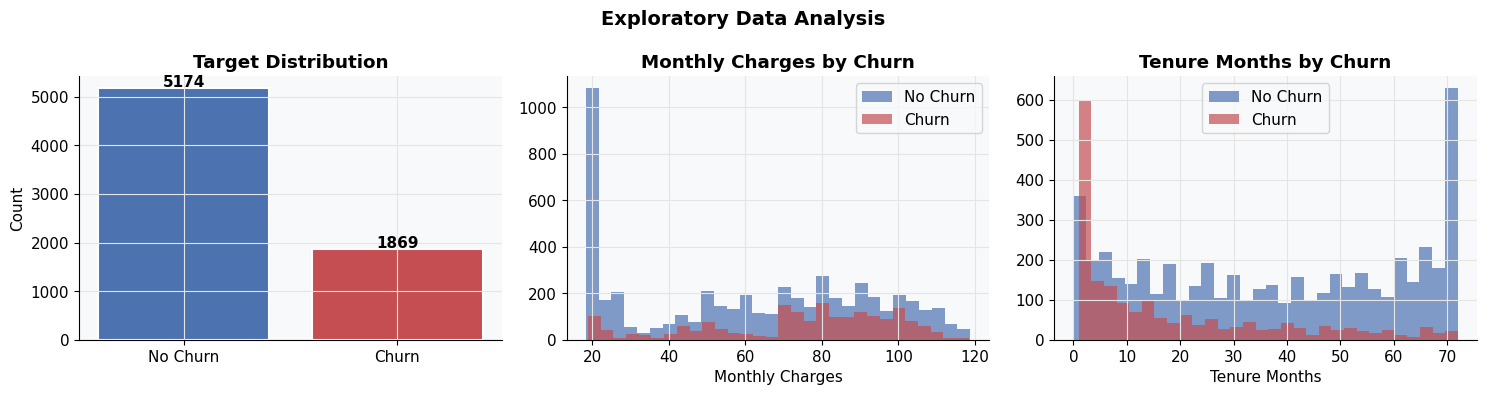

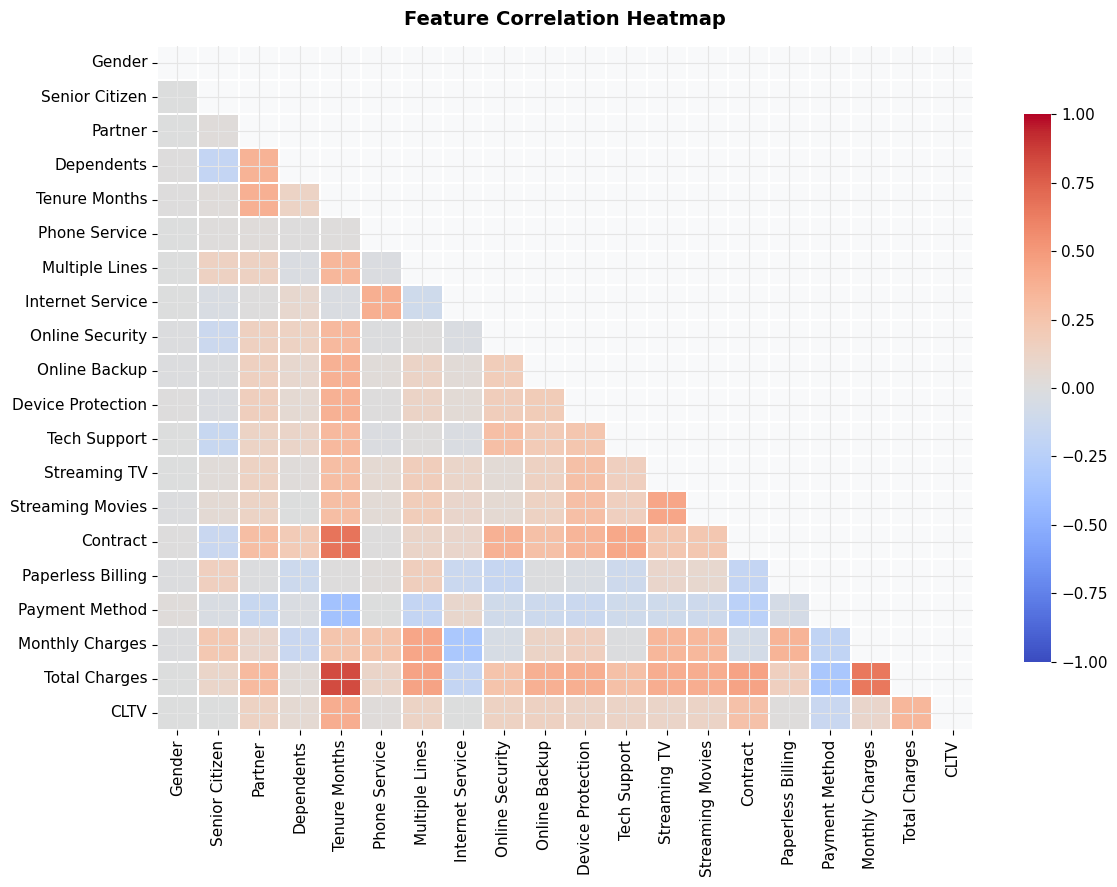

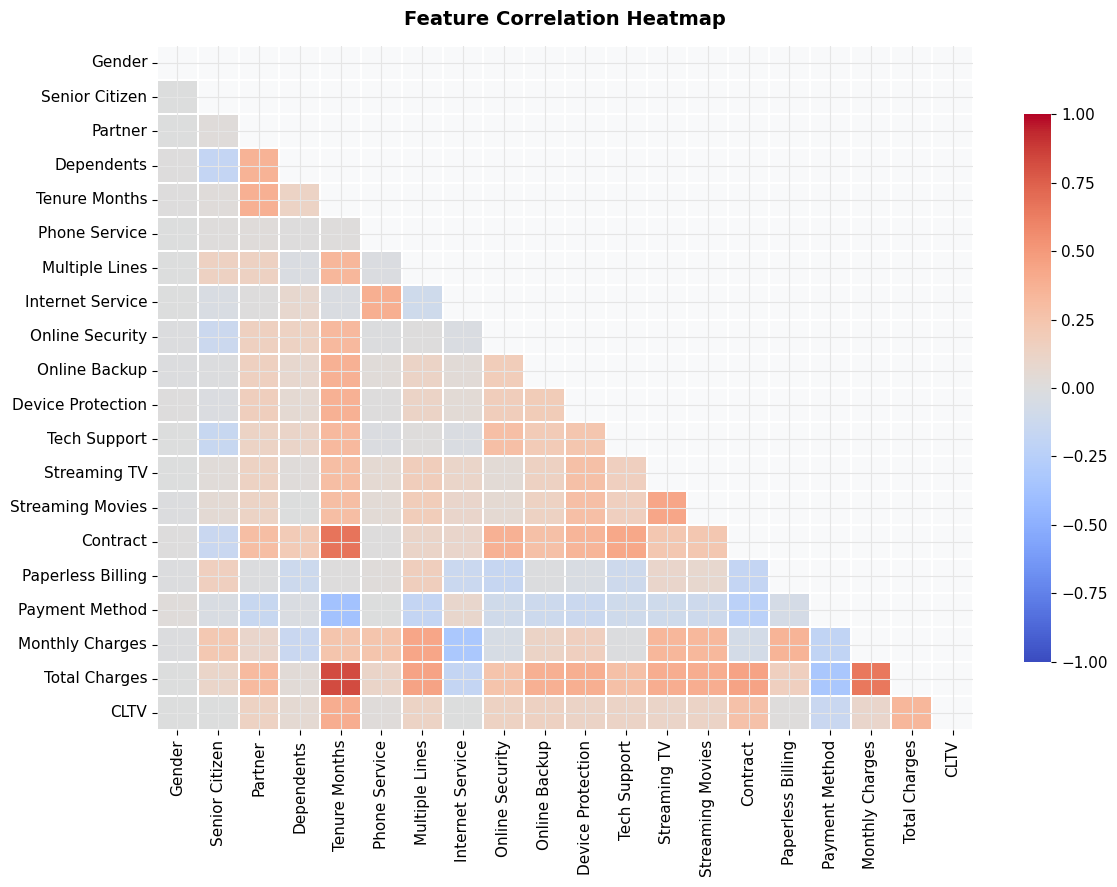

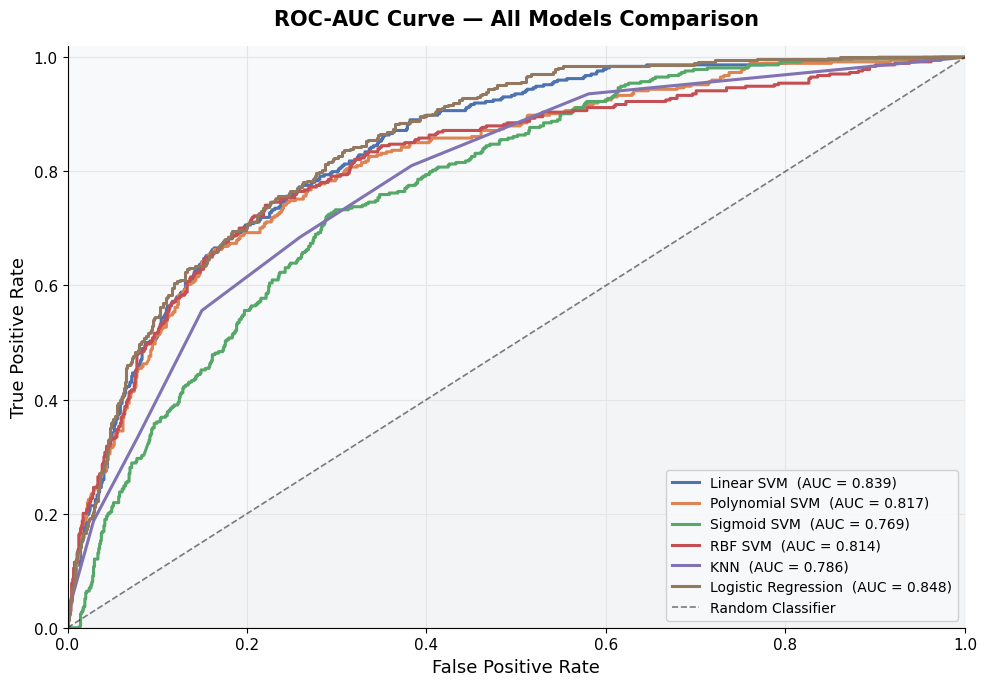

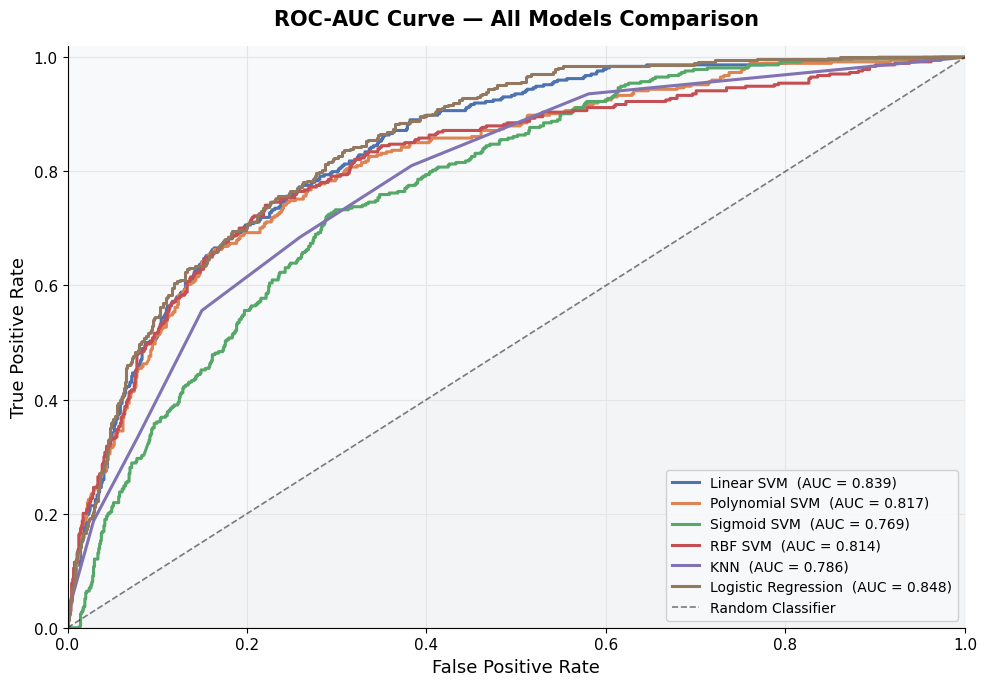

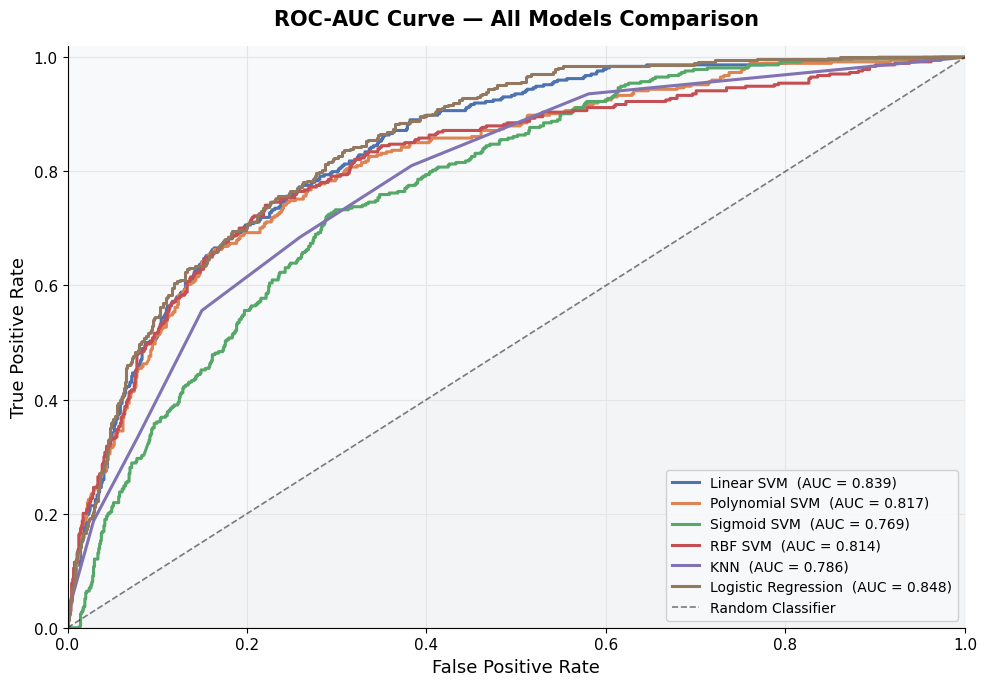

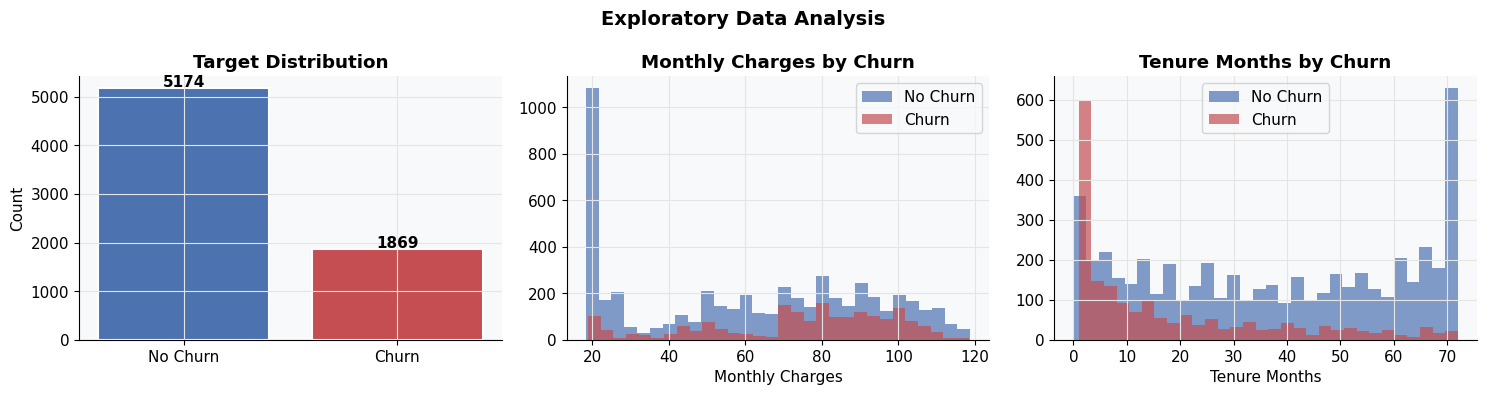

In [17]:
print("── Data Types ──────────────────────")
print(df.dtypes)
print("\n── Missing Values ──────────────────")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n── Target Distribution ─────────────")
print(df['Churn Value'].value_counts())
print(f"\nChurn Rate: {df['Churn Value'].mean()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')

# Churn distribution
churn_counts = df['Churn Value'].value_counts()
axes[0].bar(['No Churn', 'Churn'], churn_counts.values,
            color=[COLORS['linear'], COLORS['rbf']], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Monthly Charges distribution
axes[1].hist(df[df['Churn Value']==0]['Monthly Charges'], bins=30,
             alpha=0.7, color=COLORS['linear'], label='No Churn')
axes[1].hist(df[df['Churn Value']==1]['Monthly Charges'], bins=30,
             alpha=0.7, color=COLORS['rbf'], label='Churn')
axes[1].set_title('Monthly Charges by Churn', fontweight='bold')
axes[1].set_xlabel('Monthly Charges')
axes[1].legend()

# Tenure distribution
axes[2].hist(df[df['Churn Value']==0]['Tenure Months'], bins=30,
             alpha=0.7, color=COLORS['linear'], label='No Churn')
axes[2].hist(df[df['Churn Value']==1]['Tenure Months'], bins=30,
             alpha=0.7, color=COLORS['rbf'], label='Churn')
axes[2].set_title('Tenure Months by Churn', fontweight='bold')
axes[2].set_xlabel('Tenure Months')
axes[2].legend()

plt.tight_layout()
plt.show()

<h3>Pre Processing</h3>

In [18]:
# Drop non-predictive / leakage columns
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City',
             'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
             'Churn Label', 'Churn Score', 'Churn Reason']
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Fix Total Charges (mixed type)
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce')
df_clean['Total Charges'].fillna(df_clean['Total Charges'].median(), inplace=True)

TARGET = 'Churn Value'
X_raw = df_clean.drop(columns=[TARGET])
y     = df_clean[TARGET]

# Separate column types
cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
num_cols = X_raw.select_dtypes(include=['int64','float64']).columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"\nNumerical columns ({len(num_cols)}): {num_cols}")

# Encode categoricals
le = LabelEncoder()
X_encoded = X_raw.copy()
for col in cat_cols:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Impute + Scale
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_encoded)
scaler = StandardScaler()
X_processed = scaler.fit_transform(X_imputed)
X_processed_df = pd.DataFrame(X_processed, columns=X_encoded.columns)

# Raw numeric-only (for KNN raw comparison)
X_raw_num = X_raw[num_cols].fillna(X_raw[num_cols].median())

# Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y)
X_tr_raw, X_te_raw, _, _ = train_test_split(
    X_raw_num.values, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n✔ Train: {X_tr.shape[0]} samples  |  Test: {X_te.shape[0]} samples")
print("✔ Preprocessing complete")

Categorical columns (16): ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Numerical columns (4): ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

✔ Train: 5634 samples  |  Test: 1409 samples
✔ Preprocessing complete


<h3>Correaltional Heatmap</h3>

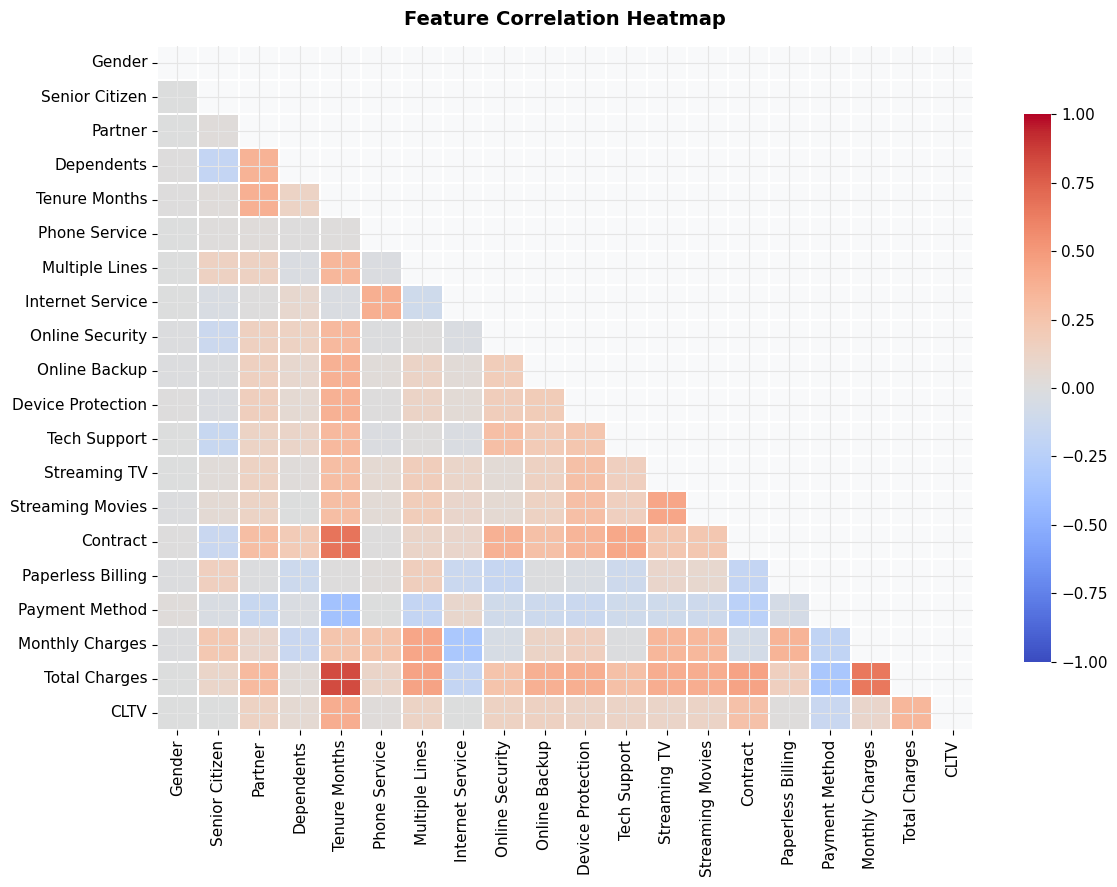

In [19]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = X_processed_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8},
            annot=False, fmt='.2f', vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

<h3>Training models</h3>

In [20]:
svm_models = {
    'Linear SVM':     SVC(kernel='linear',  probability=True, random_state=42, C=1.0),
    'Polynomial SVM': SVC(kernel='poly',    probability=True, random_state=42, degree=3, C=1.0),
    'Sigmoid SVM':    SVC(kernel='sigmoid', probability=True, random_state=42, C=1.0),
    'RBF SVM':        SVC(kernel='rbf',     probability=True, random_state=42, C=1.0),
}
other_models = {
    'KNN':                KNeighborsClassifier(n_neighbors=7),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}
all_models = {**svm_models, **other_models}

results = {}
print(f"{'Model':<24} {'Accuracy':>10} {'AUC':>10}")
print("-" * 46)
for name, model in all_models.items():
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    results[name] = {
        'model': model, 'acc': acc, 'auc': auc,
        'fpr': fpr, 'tpr': tpr,
        'y_pred': y_pred, 'y_prob': y_prob,
        'report': classification_report(y_te, y_pred, output_dict=True)
    }
    print(f"{name:<24} {acc:>10.4f} {auc:>10.4f}")

model_names  = list(results.keys())
print("\n✔ All models trained")

Model                      Accuracy        AUC
----------------------------------------------
Linear SVM                   0.8006     0.8390
Polynomial SVM               0.7956     0.8170
Sigmoid SVM                  0.7381     0.7690
RBF SVM                      0.7999     0.8141
KNN                          0.7722     0.7865
Logistic Regression          0.8055     0.8480

✔ All models trained


<h3>ROC AUC Curve</h3>

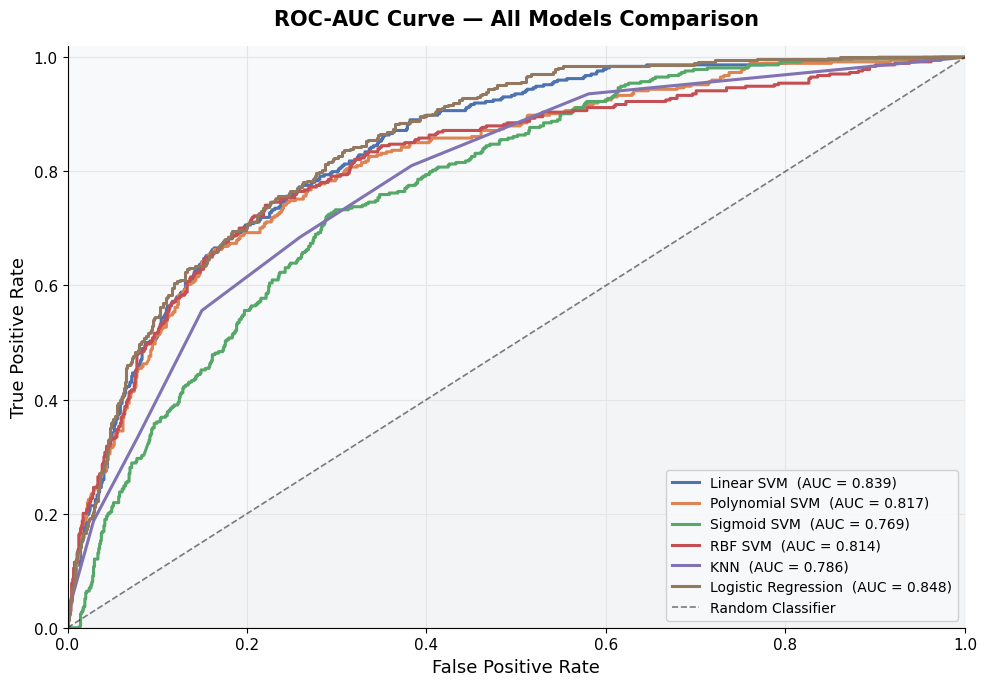

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))
for (name, res), color in zip(results.items(), MODEL_PALETTE):
    ax.plot(res['fpr'], res['tpr'], lw=2.2, color=color,
            label=f"{name}  (AUC = {res['auc']:.3f})")
ax.plot([0,1],[0,1],'k--', lw=1.2, alpha=0.5, label='Random Classifier')
ax.fill_between([0,1],[0,1], alpha=0.04, color='grey')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC-AUC Curve — All Models Comparison', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.show()

<h3>Accuracy Comparison</h3>

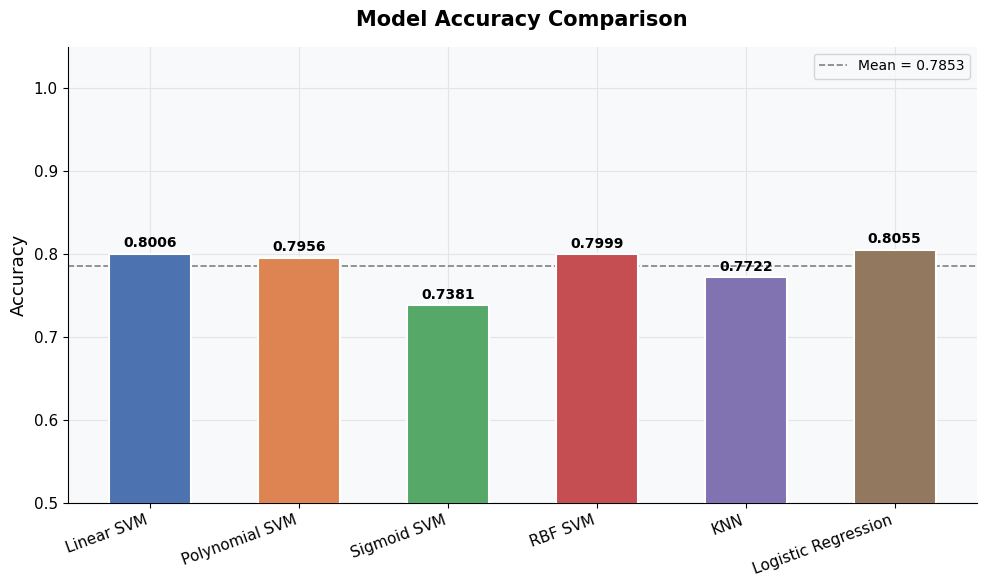

In [22]:
accs = [results[n]['acc'] for n in model_names]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, accs, color=MODEL_PALETTE, width=0.55,
              edgecolor='white', linewidth=1.5, zorder=3)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Model Accuracy Comparison', fontsize=15, fontweight='bold', pad=15)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=11)
ax.axhline(np.mean(accs), color='grey', linestyle='--', linewidth=1.2,
           label=f'Mean = {np.mean(accs):.4f}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

<h3>AUC Score Comparison</h3>

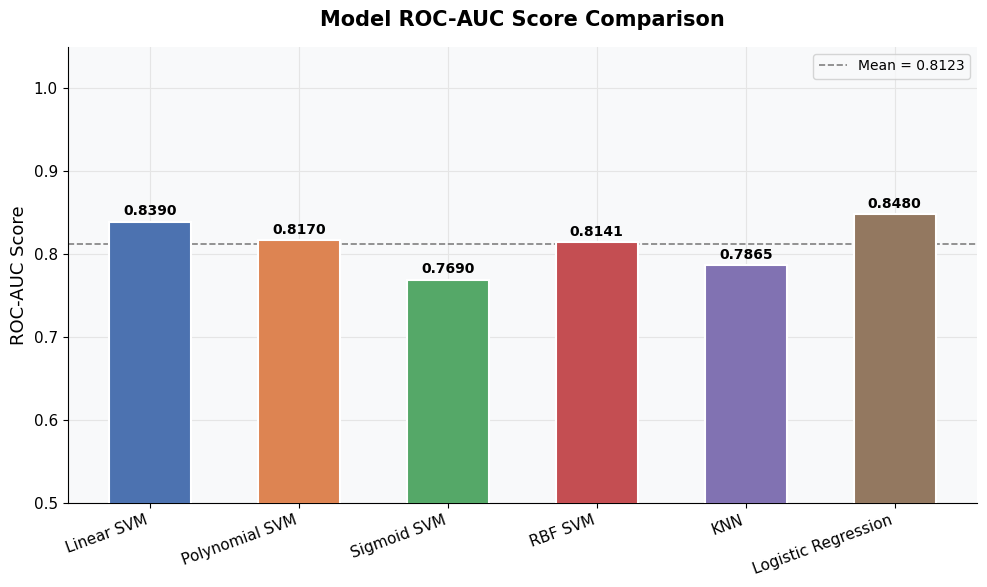

In [23]:
aucs = [results[n]['auc'] for n in model_names]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, aucs, color=MODEL_PALETTE, width=0.55,
              edgecolor='white', linewidth=1.5, zorder=3)
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f'{auc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('ROC-AUC Score', fontsize=13)
ax.set_title('Model ROC-AUC Score Comparison', fontsize=15, fontweight='bold', pad=15)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=11)
ax.axhline(np.mean(aucs), color='grey', linestyle='--', linewidth=1.2,
           label=f'Mean = {np.mean(aucs):.4f}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

<h3>Individual ROC scores</h3>

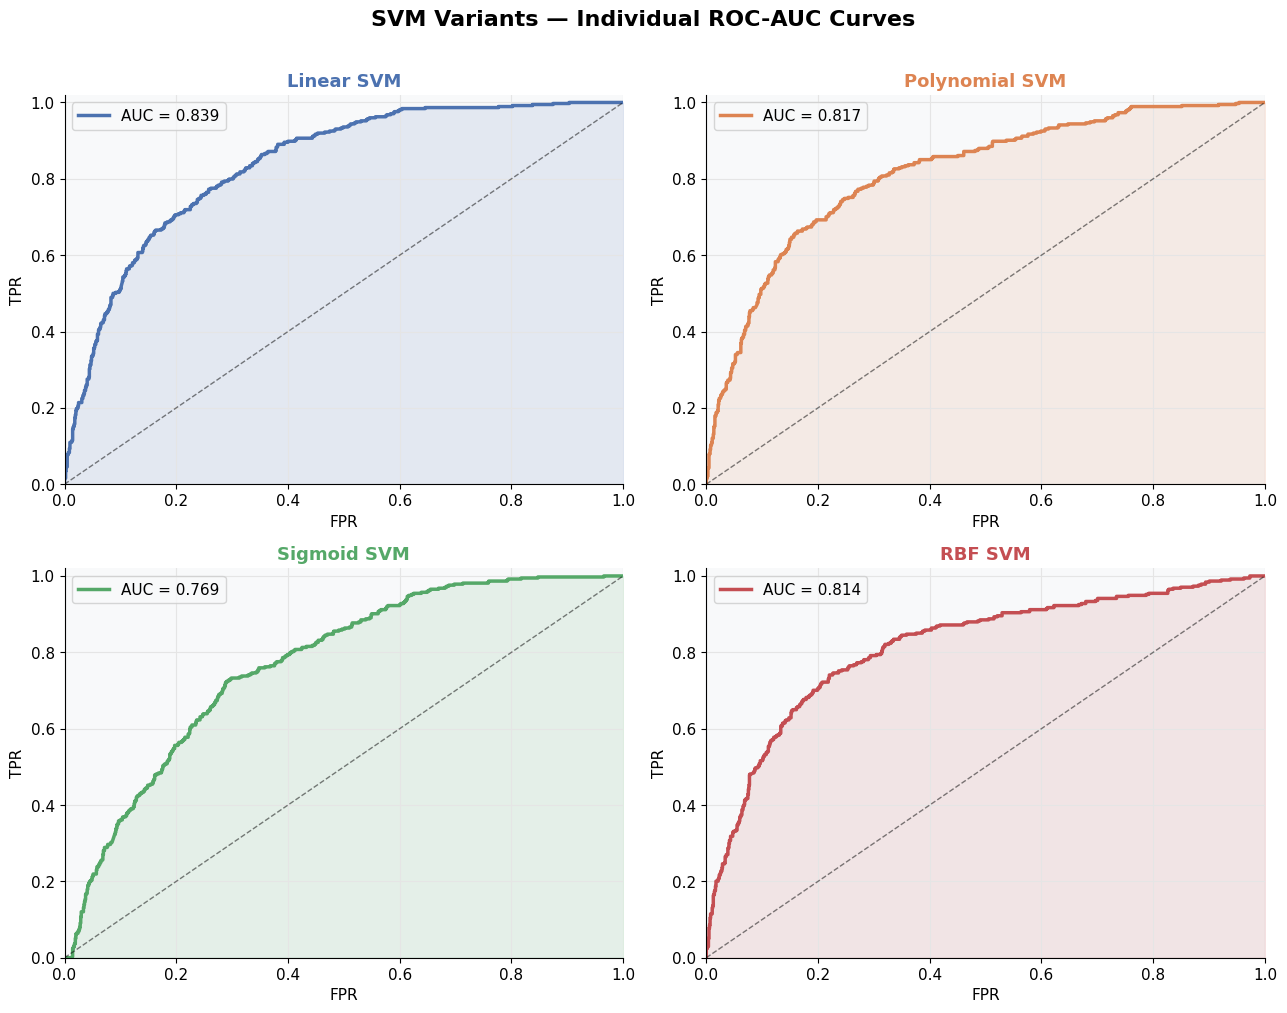

In [24]:
svm_names  = ['Linear SVM', 'Polynomial SVM', 'Sigmoid SVM', 'RBF SVM']
svm_colors = [COLORS['linear'], COLORS['poly'], COLORS['sigmoid'], COLORS['rbf']]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('SVM Variants — Individual ROC-AUC Curves', fontsize=16, fontweight='bold', y=1.01)
for ax, name, color in zip(axes.flat, svm_names, svm_colors):
    res = results[name]
    ax.plot(res['fpr'], res['tpr'], lw=2.5, color=color,
            label=f"AUC = {res['auc']:.3f}")
    ax.fill_between(res['fpr'], res['tpr'], alpha=0.12, color=color)
    ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
    ax.set_title(name, fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('FPR', fontsize=11)
    ax.set_ylabel('TPR', fontsize=11)
    ax.legend(fontsize=11)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.show()

<h3>Indiviual Graphs for kernels in SVM</h3>

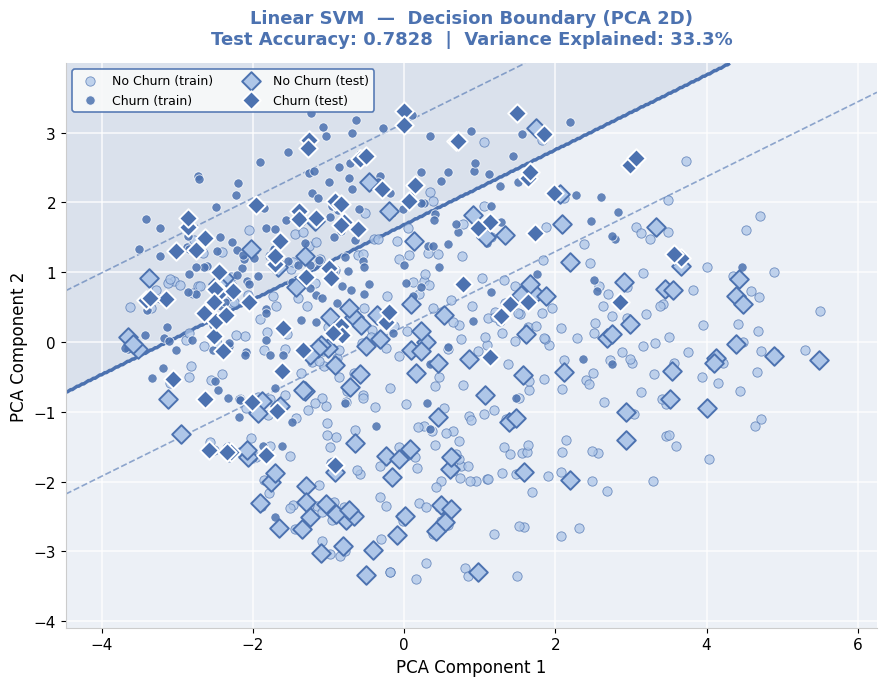

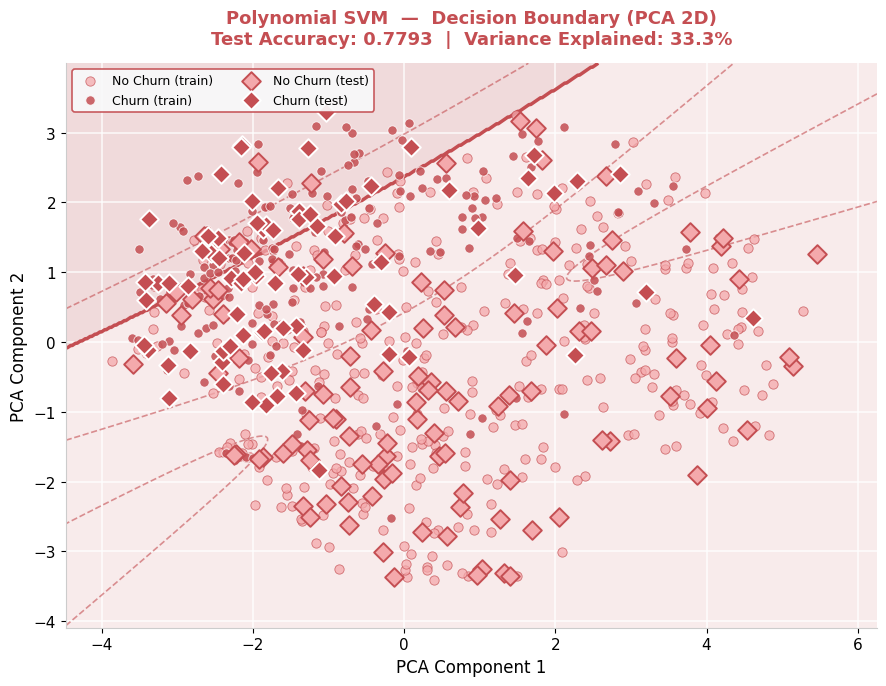

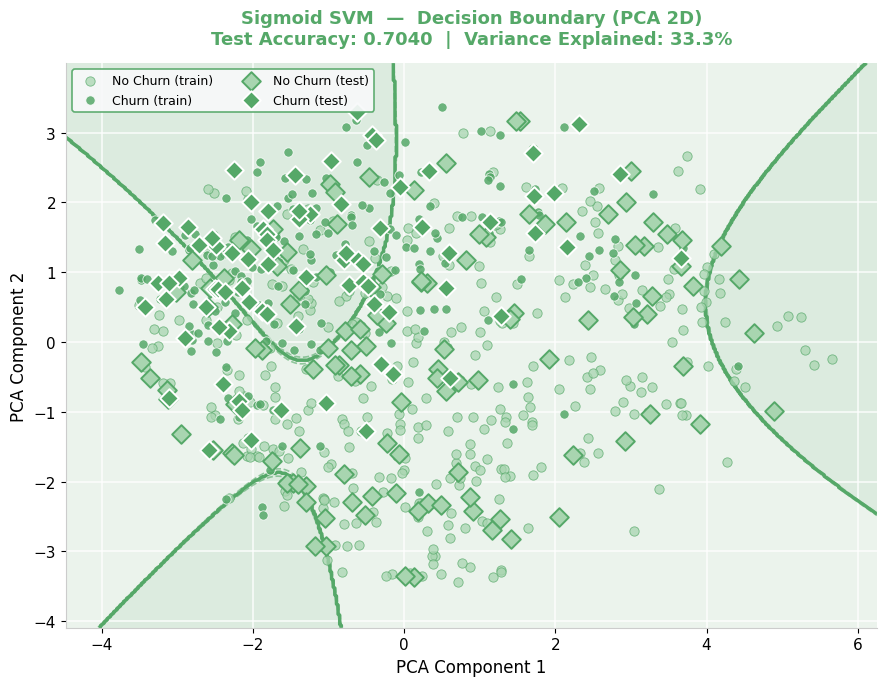

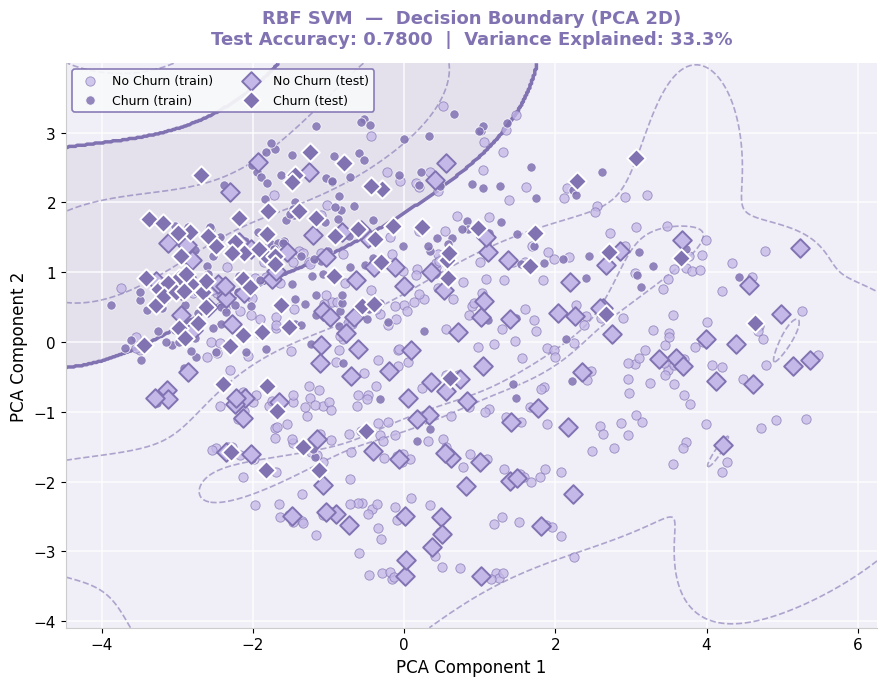

In [29]:
# ── Clean SVM Decision Boundary Diagrams (PCA 2D) ──────────────
from sklearn.decomposition import PCA
from sklearn.svm import SVC as _SVC

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

X_tr_pca, X_te_pca, y_tr_pca, y_te_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y)

svm_configs = [
    ('Linear SVM',     'linear',  '#4C72B0', '#AEC6E8', dict(C=1.0)),
    ('Polynomial SVM', 'poly',    '#C44E52', '#F4A9AC', dict(C=1.0, degree=3)),
    ('Sigmoid SVM',    'sigmoid', '#55A868', '#A8D5B0', dict(C=1.0)),
    ('RBF SVM',        'rbf',     '#8172B2', '#C4B8E8', dict(C=1.0, gamma='scale')),
]

for title, kernel, dark, light, kwargs in svm_configs:

    clf = _SVC(kernel=kernel, probability=True, **kwargs)
    clf.fit(X_tr_pca, y_tr_pca)
    acc = accuracy_score(y_te_pca, clf.predict(X_te_pca))

    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')

    # Mesh
    pad = 0.6
    x_min, x_max = X_pca[:,0].min()-pad, X_pca[:,0].max()+pad
    y_min, y_max = X_pca[:,1].min()-pad, X_pca[:,1].max()+pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5,0.5,1.5],
                colors=[light, dark], alpha=0.18)
    ax.contour(xx, yy, Z, levels=[0.5],
               colors=[dark], linewidths=2.5)

    # Margins (only for kernels that support it cleanly)
    try:
        Zd = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contour(xx, yy, Zd, levels=[-1, 1],
                   colors=[dark], linewidths=1.2, linestyles='--', alpha=0.6)
    except:
        pass

    # Sample subset for cleaner plot (avoid overplotting)
    idx0 = np.where(y_tr_pca == 0)[0]
    idx1 = np.where(y_tr_pca == 1)[0]
    s0   = idx0[np.random.choice(len(idx0), min(350, len(idx0)), replace=False)]
    s1   = idx1[np.random.choice(len(idx1), min(200, len(idx1)), replace=False)]

    ax.scatter(X_tr_pca[s0,0], X_tr_pca[s0,1],
               c=light, edgecolors=dark, s=45, alpha=0.75,
               linewidths=0.6, label='No Churn (train)', zorder=3)
    ax.scatter(X_tr_pca[s1,0], X_tr_pca[s1,1],
               c=dark, edgecolors='white', s=45, alpha=0.85,
               linewidths=0.6, label='Churn (train)', zorder=3)

    # Test points — distinct style
    te0 = np.where(y_te_pca == 0)[0]
    te1 = np.where(y_te_pca == 1)[0]
    ts0 = te0[np.random.choice(len(te0), min(120, len(te0)), replace=False)]
    ts1 = te1[np.random.choice(len(te1), min(80,  len(te1)), replace=False)]

    ax.scatter(X_te_pca[ts0,0], X_te_pca[ts0,1],
               c=light, edgecolors=dark, s=90, alpha=1.0,
               linewidths=1.4, marker='D', label='No Churn (test)', zorder=4)
    ax.scatter(X_te_pca[ts1,0], X_te_pca[ts1,1],
               c=dark, edgecolors='white', s=90, alpha=1.0,
               linewidths=1.4, marker='D', label='Churn (test)', zorder=4)

    # Support vectors — small, subtle
    if hasattr(clf, 'support_vectors_') and len(clf.support_vectors_) < 600:
        sv = clf.support_vectors_
        ax.scatter(sv[:,0], sv[:,1], s=120, facecolors='none',
                   edgecolors=dark, linewidths=1.5,
                   label=f'Support Vectors ({len(sv)})', zorder=5, alpha=0.5)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('PCA Component 1', fontsize=12)
    ax.set_ylabel('PCA Component 2', fontsize=12)
    ax.set_title(f'{title}  —  Decision Boundary (PCA 2D)\nTest Accuracy: {acc:.4f}  '
                 f'|  Variance Explained: {pca.explained_variance_ratio_.sum()*100:.1f}%',
                 fontsize=13, fontweight='bold', color=dark, pad=14)

    legend = ax.legend(fontsize=9, loc='upper left', framealpha=0.92,
                       edgecolor=dark, fancybox=True, ncol=2)
    legend.get_frame().set_linewidth(1.2)

    ax.set_facecolor('#FAFAFA')
    ax.grid(True, color='white', linewidth=1.2, alpha=0.8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')

    plt.tight_layout()
    plt.show()
    print()

<h3>KNN Raw vs Processed data</h3>

KNN Raw       → Accuracy: 0.7260  |  AUC: 0.6506
KNN Processed → Accuracy: 0.7722  |  AUC: 0.7865


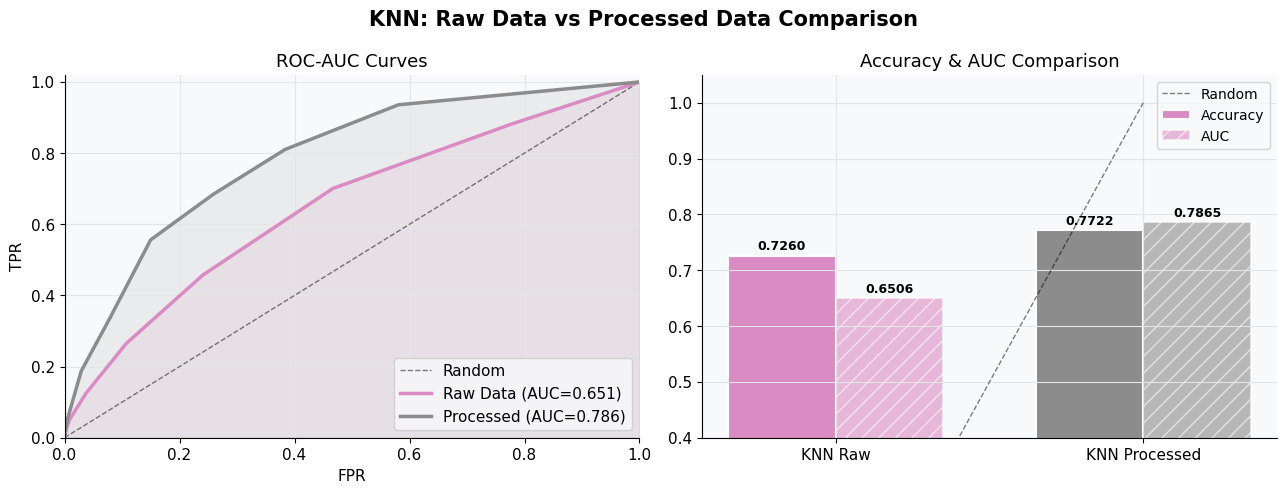

In [25]:
knn_raw  = KNeighborsClassifier(n_neighbors=7).fit(X_tr_raw, y_tr)
knn_proc = KNeighborsClassifier(n_neighbors=7).fit(X_tr, y_tr)

knn_raw_acc  = accuracy_score(y_te, knn_raw.predict(X_te_raw))
knn_proc_acc = accuracy_score(y_te, knn_proc.predict(X_te))
knn_raw_auc  = roc_auc_score(y_te, knn_raw.predict_proba(X_te_raw)[:,1])
knn_proc_auc = roc_auc_score(y_te, knn_proc.predict_proba(X_te)[:,1])
knn_raw_fpr,  knn_raw_tpr,  _ = roc_curve(y_te, knn_raw.predict_proba(X_te_raw)[:,1])
knn_proc_fpr, knn_proc_tpr, _ = roc_curve(y_te, knn_proc.predict_proba(X_te)[:,1])

print(f"KNN Raw       → Accuracy: {knn_raw_acc:.4f}  |  AUC: {knn_raw_auc:.4f}")
print(f"KNN Processed → Accuracy: {knn_proc_acc:.4f}  |  AUC: {knn_proc_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('KNN: Raw Data vs Processed Data Comparison', fontsize=15, fontweight='bold')

# ROC
for ax in axes:
    ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random')
axes[0].plot(knn_raw_fpr,  knn_raw_tpr,  lw=2.5, color=COLORS['knn_raw'],
             label=f"Raw Data (AUC={knn_raw_auc:.3f})")
axes[0].fill_between(knn_raw_fpr,  knn_raw_tpr,  alpha=0.12, color=COLORS['knn_raw'])
axes[0].plot(knn_proc_fpr, knn_proc_tpr, lw=2.5, color=COLORS['knn_proc'],
             label=f"Processed (AUC={knn_proc_auc:.3f})")
axes[0].fill_between(knn_proc_fpr, knn_proc_tpr, alpha=0.12, color=COLORS['knn_proc'])
axes[0].set_title('ROC-AUC Curves', fontsize=13)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(fontsize=11); axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])

# Bar chart
x = np.arange(2); w = 0.35
b1 = axes[1].bar(x - w/2, [knn_raw_acc, knn_proc_acc], w, label='Accuracy',
                  color=[COLORS['knn_raw'], COLORS['knn_proc']], edgecolor='white', linewidth=1.5)
b2 = axes[1].bar(x + w/2, [knn_raw_auc, knn_proc_auc], w, label='AUC',
                  color=[COLORS['knn_raw'], COLORS['knn_proc']], alpha=0.6,
                  edgecolor='white', linewidth=1.5, hatch='//')
for bar, val in zip(list(b1)+list(b2),
                    [knn_raw_acc, knn_proc_acc, knn_raw_auc, knn_proc_auc]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(['KNN Raw','KNN Processed'], fontsize=11)
axes[1].set_ylim(0.4, 1.05)
axes[1].set_title('Accuracy & AUC Comparison', fontsize=13)
axes[1].legend(fontsize=10)
plt.tight_layout()
plt.show()